In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("Laptop.csv")

In [4]:
df.head()

,ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram (GB),Memory,Gpu,OpSys,Weight (Kg),Price_euros
0,6,Acer,Aspire 3,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4,500GB HDD,AMD Radeon R5,Windows 10,2.1,400.0
1,9,Asus,ZenBook UX430UN,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16,512GB SSD,Nvidia GeForce MX150,Windows 10,1.3,1495.0
2,10,Acer,Swift 3,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6,770.0
3,14,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,4,256GB SSD,AMD Radeon R5 M430,Windows 10,2.2,498.9
4,17,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8,256GB SSD,AMD Radeon R5 M430,Windows 10,2.2,745.0


In [5]:
df.isnull().sum()

ID                  0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram (GB)            0
Memory              0
Gpu                 0
OpSys               0
Weight (Kg)         0
Price_euros         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:

df.columns

Index(['ID', 'Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram (GB)', 'Memory', 'Gpu', 'OpSys', 'Weight (Kg)',
       'Price_euros'],
      dtype='str')

In [9]:
df.dtypes

ID                    int64
Company                 str
Product                 str
TypeName                str
Inches              float64
ScreenResolution        str
Cpu                     str
Ram (GB)              int64
Memory                  str
Gpu                     str
OpSys                   str
Weight (Kg)         float64
Price_euros         float64
dtype: object

In [10]:
print(df["Company"].unique())
print(df["OpSys"].unique())
print(df["TypeName"].unique())


<ArrowStringArray>
[     'Acer',      'Asus',      'Dell',    'Lenovo',        'HP',     'Chuwi',
       'MSI', 'Microsoft',   'Toshiba',    'Huawei',      'Vero',     'Razer',
  'Mediacom',   'Fujitsu',   'Samsung',        'LG',    'Xiaomi']
Length: 17, dtype: str
<ArrowStringArray>
['Windows 10', 'Windows 10 S']
Length: 2, dtype: str
<ArrowStringArray>
[          'Notebook',          'Ultrabook',            'Netbook',
             'Gaming', '2 in 1 Convertible',        'Workstation']
Length: 6, dtype: str


In [11]:
df["Price_euros"].describe()

count    1080.000000
mean     1169.016074
std       696.498381
min       191.900000
25%       655.007500
50%      1019.495000
75%      1515.642500
max      6099.000000
Name: Price_euros, dtype: float64

In [12]:
print("Minimum Price:", df["Price_euros"].min())
print("Maximum Price:", df["Price_euros"].max())

Minimum Price: 191.9
Maximum Price: 6099.0


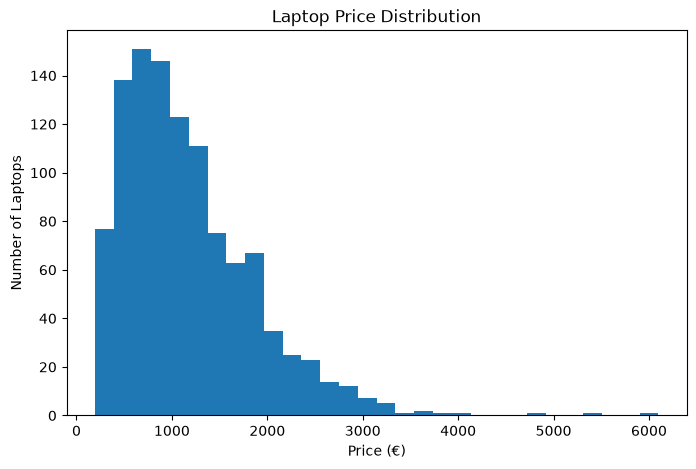

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["Price_euros"], bins=30)

plt.title("Laptop Price Distribution")
plt.xlabel("Price (€)")
plt.ylabel("Number of Laptops")

plt.show()

In [14]:
brand_price = df.groupby("Company")["Price_euros"].mean().sort_values(ascending=False)

print(brand_price)

Company
Razer        3346.142857
LG           2099.000000
MSI          1728.908148
Samsung      1684.714286
Microsoft    1612.308333
Huawei       1424.000000
Toshiba      1265.217391
Dell         1260.711858
Lenovo       1169.108534
Asus         1162.119787
HP           1034.665532
Xiaomi        935.000000
Fujitsu       729.000000
Acer          693.990921
Chuwi         314.296667
Mediacom      295.000000
Vero          217.425000
Name: Price_euros, dtype: float64


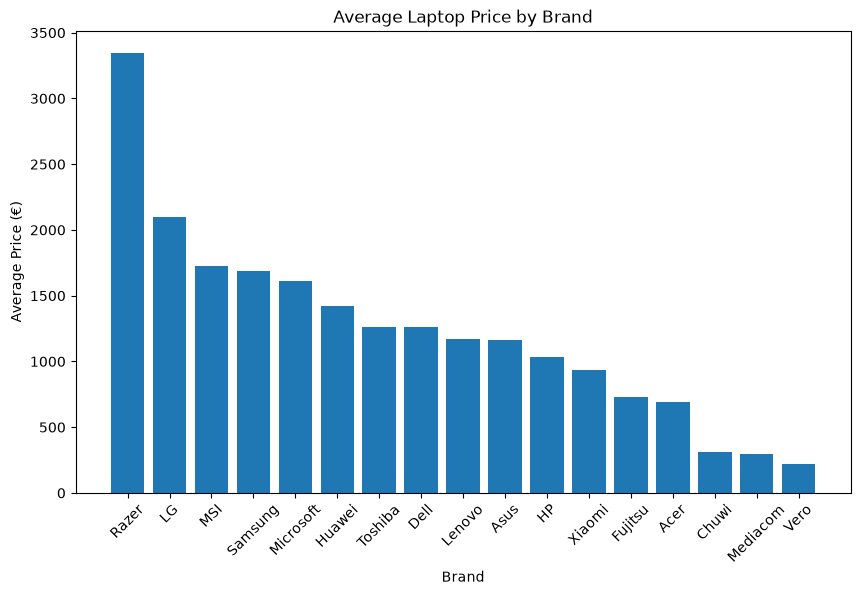

In [15]:
plt.figure(figsize=(10,6))

plt.bar(brand_price.index, brand_price.values)

plt.title("Average Laptop Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price (€)")

plt.xticks(rotation=45)
plt.show()

In [16]:
ram_price = df.groupby("Ram (GB)")["Price_euros"].mean()

print(ram_price)

Ram (GB)
2      257.534211
4      605.323718
6      615.206341
8     1192.913949
12    1205.998261
16    1920.183189
24    2206.333333
32    3413.085882
64    3975.000000
Name: Price_euros, dtype: float64


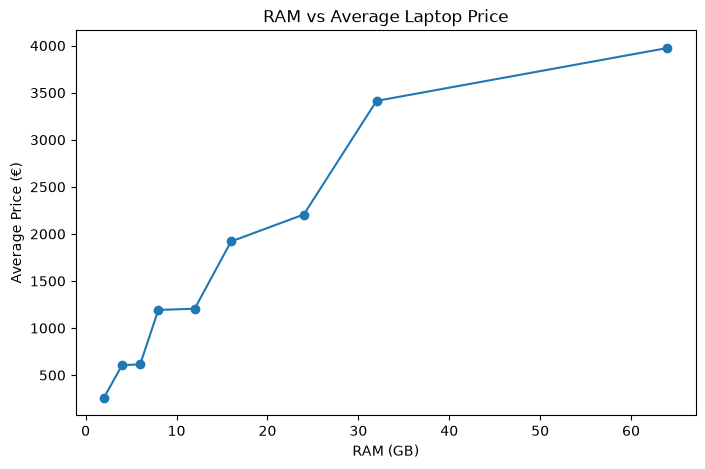

In [17]:
plt.figure(figsize=(8,5))

plt.plot(ram_price.index, ram_price.values, marker="o")

plt.title("RAM vs Average Laptop Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Average Price (€)")

plt.show()

In [18]:
print(df["Memory"].value_counts())

Memory
256GB SSD                        353
1TB HDD                          166
512GB SSD                        104
500GB HDD                        102
128GB SSD +  1TB HDD              89
256GB SSD +  1TB HDD              72
128GB SSD                         64
32GB Flash Storage                28
512GB SSD +  1TB HDD              14
1TB SSD                           14
2TB HDD                           12
64GB Flash Storage                10
256GB SSD +  2TB HDD               9
1.0TB Hybrid                       7
32GB SSD                           5
180GB SSD                          4
512GB SSD +  2TB HDD               3
256GB SSD +  256GB SSD             2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
128GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB Flash Storage                2
64GB SSD                           1
512GB SSD +  512GB SSD             1
512GB SSD +  256GB SSD             1
64GB Flash Storage +  1TB HDD  

In [19]:
print("SSD:", df["Memory"].str.contains("SSD", case=False).sum())
print("HDD:", df["Memory"].str.contains("HDD", case=False).sum())

SSD: 746
HDD: 478


In [20]:
df["Storage_Type"] = df["Memory"].apply(
    lambda x: "SSD" if "SSD" in x.upper()
    else "HDD" if "HDD" in x.upper()
    else "Other"
)

print(df["Storage_Type"].value_counts())

Storage_Type
SSD      746
HDD      285
Other     49
Name: count, dtype: int64


In [21]:
storage_price = df.groupby("Storage_Type")["Price_euros"].mean()

print(storage_price)

Storage_Type
HDD       687.133474
Other     425.870816
SSD      1401.925804
Name: Price_euros, dtype: float64


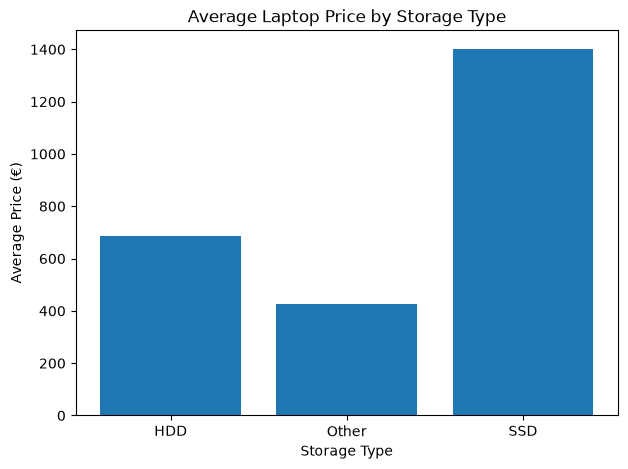

In [22]:
plt.figure(figsize=(7,5))

plt.bar(storage_price.index, storage_price.values)

plt.title("Average Laptop Price by Storage Type")
plt.xlabel("Storage Type")
plt.ylabel("Average Price (€)")

plt.show()

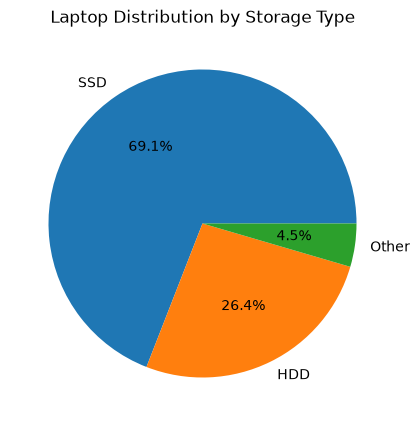

In [23]:
plt.figure(figsize=(7,5))

df["Storage_Type"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Laptop Distribution by Storage Type")
plt.ylabel("")

plt.show()

In [24]:
print(df["Cpu"].value_counts().head(15))

Cpu
Intel Core i5 7200U 2.5GHz              166
Intel Core i7 7700HQ 2.8GHz             136
Intel Core i7 7500U 2.7GHz              120
Intel Core i7 8550U 1.8GHz               68
Intel Core i5 8250U 1.6GHz               67
Intel Core i3 6006U 2GHz                 45
Intel Core i5 6200U 2.3GHz               44
Intel Core i7 6500U 2.5GHz               41
Intel Core i7 6700HQ 2.6GHz              37
Intel Core i3 7100U 2.4GHz               35
Intel Core i5 7300HQ 2.5GHz              27
Intel Celeron Dual Core N3350 1.1GHz     23
Intel Core i7 6600U 2.6GHz               13
Intel Core i5 7300U 2.6GHz               13
Intel Core i7 7600U 2.8GHz               12
Name: count, dtype: int64


In [25]:
cpu_price = df.groupby("Cpu")["Price_euros"].mean().sort_values(ascending=False)

print(cpu_price.head(15))

Cpu
Intel Xeon E3-1535M v6 3.1GHz    4899.000000
Intel Core i7 7820HK 2.9GHz      3832.678571
Intel Core i7 6920HQ 2.9GHz      2799.000000
Intel Core i7 6820HK 2.7GHz      2555.763000
Intel Xeon E3-1505M V6 3GHz      2524.000000
Intel Core i7 6820HQ 2.7GHz      2219.200000
Intel Core i7 7660U 2.5GHz       2209.333333
Intel Core M 6Y75 1.2GHz         2077.200000
Intel Core i7 7820HQ 2.9GHz      2076.972000
Intel Core i7 7700HQ 2.7GHz      2046.000000
Intel Core i7 7600U 2.8GHz       1983.770000
Intel Core i7 6600U 2.6GHz       1911.843846
Intel Core i7 7700HQ 2.8GHz      1816.717868
Intel Core i7 6560U 2.2GHz       1799.000000
Intel Core i7 7500U 2.5GHz       1799.000000
Name: Price_euros, dtype: float64


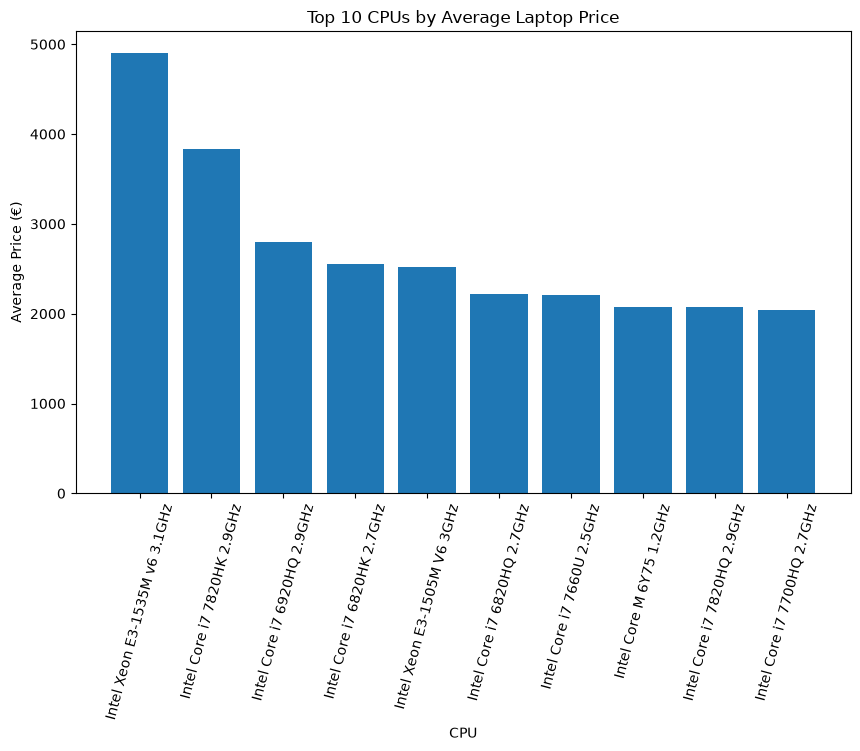

In [26]:
top_cpu = cpu_price.head(10)

plt.figure(figsize=(10,6))

plt.bar(top_cpu.index, top_cpu.values)

plt.title("Top 10 CPUs by Average Laptop Price")
plt.xlabel("CPU")
plt.ylabel("Average Price (€)")
plt.xticks(rotation=75)

plt.show()

In [27]:
print(df["Gpu"].value_counts().head(15))

Gpu
Intel HD Graphics 620         263
Intel HD Graphics 520         130
Intel UHD Graphics 620         68
Nvidia GeForce GTX 1050        58
Nvidia GeForce GTX 1060        45
AMD Radeon 530                 38
Nvidia GeForce 940MX           36
Intel HD Graphics 500          31
Nvidia GeForce GTX 1070        30
Nvidia GeForce GTX 1050 Ti     25
Intel HD Graphics              22
Nvidia GeForce 930MX           19
Intel HD Graphics 400          17
AMD Radeon 520                 14
Nvidia GeForce GTX 960M        14
Name: count, dtype: int64


In [28]:
gpu_price = df.groupby("Gpu")["Price_euros"].mean().sort_values(ascending=False)

print(gpu_price.head(15))

Gpu
Nvidia GeForce GTX 1080     4007.333333
Nvidia GeForce GTX 980      3975.000000
Nvidia GeForce GTX 1070M    3588.800000
Nvidia Quadro M520M         3299.000000
Nvidia Quadro M2200M        3146.000000
Nvidia Quadro M620M         2999.000000
Nvidia GeForce GTX1080      2968.000000
Nvidia GTX 980 SLI          2799.000000
Nvidia GeForce GTX 1070     2611.805333
Nvidia Quadro M1200         2291.901111
Nvidia GeForce 960M         2250.680000
Nvidia Quadro M1000M        2249.000000
Nvidia Quadro M2200         2241.950000
Nvidia GeForce GTX 980M     2210.062000
Nvidia Quadro M620          1969.400000
Name: Price_euros, dtype: float64


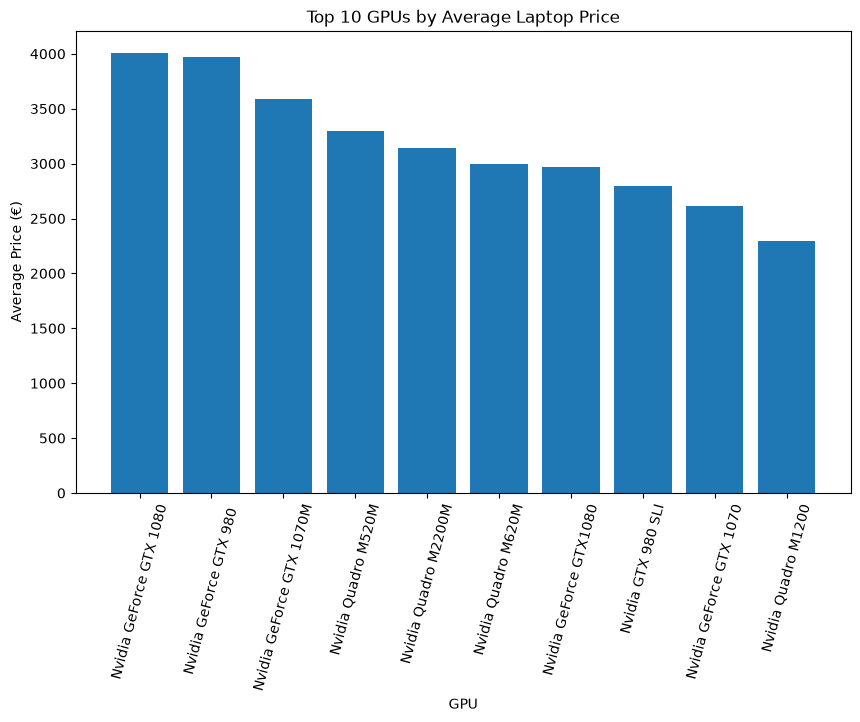

In [29]:
top_gpu = gpu_price.head(10)

plt.figure(figsize=(10,6))

plt.bar(top_gpu.index, top_gpu.values)

plt.title("Top 10 GPUs by Average Laptop Price")
plt.xlabel("GPU")
plt.ylabel("Average Price (€)")
plt.xticks(rotation=75)

plt.show()

In [30]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

print(numeric_df.columns)

Index(['ID', 'Inches', 'Ram (GB)', 'Weight (Kg)', 'Price_euros'], dtype='str')


In [31]:
price_corr = numeric_df.corr()["Price_euros"].sort_values(ascending=False)

print(price_corr)

Price_euros    1.000000
Ram (GB)       0.752227
Weight (Kg)    0.242982
Inches         0.082581
ID             0.065330
Name: Price_euros, dtype: float64


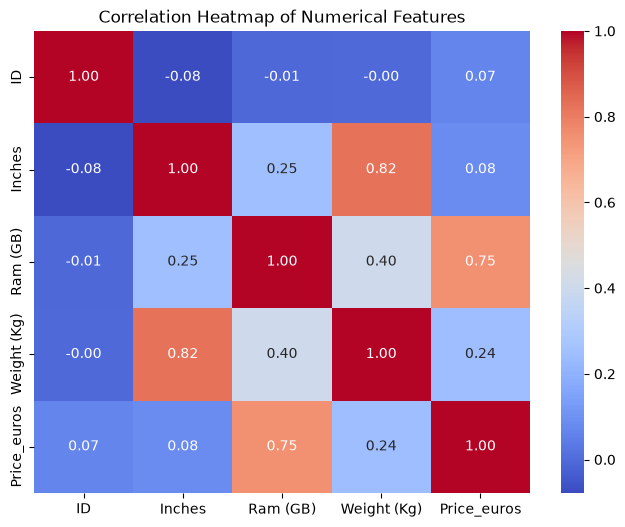

In [32]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

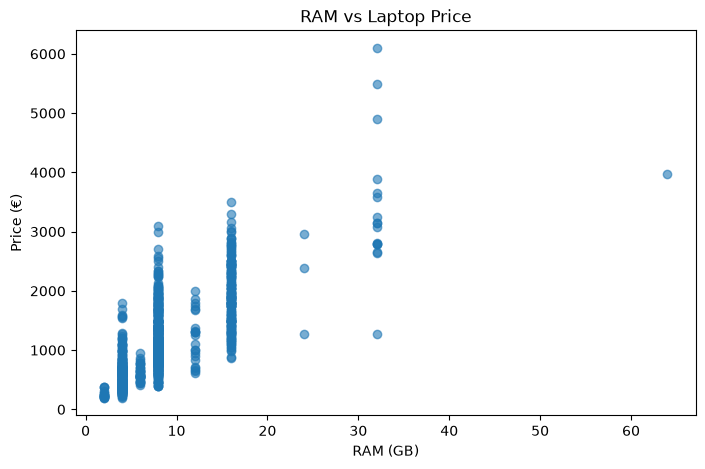

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Ram (GB)"],
    df["Price_euros"],
    alpha=0.6
)

plt.title("RAM vs Laptop Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (€)")

plt.show()

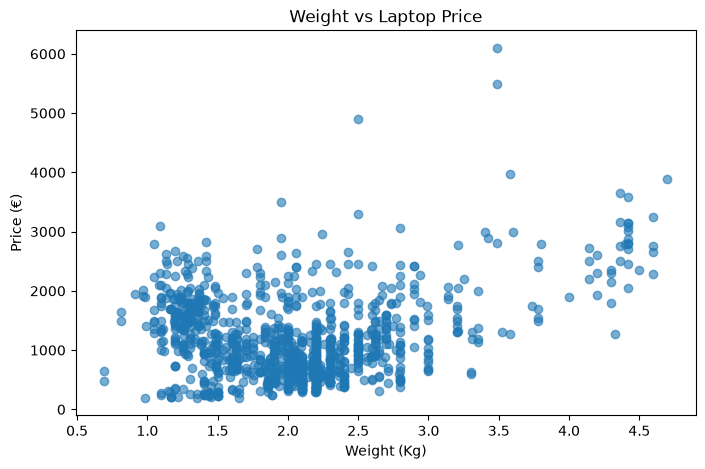

In [34]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Weight (Kg)"],
    df["Price_euros"],
    alpha=0.6
)

plt.title("Weight vs Laptop Price")
plt.xlabel("Weight (Kg)")
plt.ylabel("Price (€)")

plt.show()

In [35]:
df["CPU_Brand"] = df["Cpu"].str.split().str[0]

print(df["CPU_Brand"].value_counts())



CPU_Brand
Intel    1020
AMD        60
Name: count, dtype: int64


In [36]:
df["GPU_Brand"] = df["Gpu"].str.split().str[0]

print(df["GPU_Brand"].value_counts())

GPU_Brand
Intel     584
Nvidia    351
AMD       145
Name: count, dtype: int64


In [37]:
print(df["ScreenResolution"].head(10))

0                                     1366x768
1                            Full HD 1920x1080
2                  IPS Panel Full HD 1920x1080
3                            Full HD 1920x1080
4                            Full HD 1920x1080
5    IPS Panel Full HD / Touchscreen 1920x1080
6                                     1366x768
7                  IPS Panel Full HD 1920x1080
8              Full HD / Touchscreen 1920x1080
9                            Full HD 1920x1080
Name: ScreenResolution, dtype: str


In [38]:
df["Resolution"] = df["ScreenResolution"].str.extract(
    r"(\d+x\d+)"
)

df["Resolution_Width"] = (
    df["Resolution"].str.split("x").str[0].astype(int)
)

df["Resolution_Height"] = (
    df["Resolution"].str.split("x").str[1].astype(int)
)

In [39]:
df["Pixels"] = (
    df["Resolution_Width"] *
    df["Resolution_Height"]
)

print(df[[
    "ScreenResolution",
    "Resolution_Width",
    "Resolution_Height",
    "Pixels"
]].head())

              ScreenResolution  Resolution_Width  Resolution_Height   Pixels
0                     1366x768              1366                768  1049088
1            Full HD 1920x1080              1920               1080  2073600
2  IPS Panel Full HD 1920x1080              1920               1080  2073600
3            Full HD 1920x1080              1920               1080  2073600
4            Full HD 1920x1080              1920               1080  2073600


In [40]:
df["Storage_GB"] = df["Memory"].str.extract(
    r"(\d+)"
)[0].astype(float)

In [41]:
print(df[["Memory", "Storage_GB"]].head(15))

                    Memory  Storage_GB
0                500GB HDD       500.0
1                512GB SSD       512.0
2                256GB SSD       256.0
3                256GB SSD       256.0
4                256GB SSD       256.0
5                128GB SSD       128.0
6       32GB Flash Storage        32.0
7     128GB SSD +  1TB HDD       128.0
8                256GB SSD       256.0
9                256GB SSD       256.0
10                 1TB HDD         1.0
11               256GB SSD       256.0
12  256GB SSD +  256GB SSD       256.0
13                 1TB HDD         1.0
14      64GB Flash Storage        64.0


In [42]:
import re

def get_ssd_gb(memory):
    memory = memory.upper()
    
    ssd = re.search(r"(\d+(?:\.\d+)?)\s*(TB|GB)\s*SSD", memory)
    
    if ssd:
        value = float(ssd.group(1))
        unit = ssd.group(2)
        
        if unit == "TB":
            value *= 1024
            
        return value
    
    return 0

In [43]:
df["SSD_GB"] = df["Memory"].apply(get_ssd_gb)

In [44]:
def get_hdd_gb(memory):
    memory = memory.upper()
    
    hdd = re.search(r"(\d+(?:\.\d+)?)\s*(TB|GB)\s*HDD", memory)
    
    if hdd:
        value = float(hdd.group(1))
        unit = hdd.group(2)
        
        if unit == "TB":
            value *= 1024
            
        return value
    
    return 0

In [45]:
df["HDD_GB"] = df["Memory"].apply(get_hdd_gb)

In [46]:
df["Total_Storage_GB"] = df["SSD_GB"] + df["HDD_GB"]

In [47]:
print(
    df[
        ["Memory", "SSD_GB", "HDD_GB", "Total_Storage_GB"]
    ].head(20)
)

                    Memory  SSD_GB  HDD_GB  Total_Storage_GB
0                500GB HDD     0.0   500.0             500.0
1                512GB SSD   512.0     0.0             512.0
2                256GB SSD   256.0     0.0             256.0
3                256GB SSD   256.0     0.0             256.0
4                256GB SSD   256.0     0.0             256.0
5                128GB SSD   128.0     0.0             128.0
6       32GB Flash Storage     0.0     0.0               0.0
7     128GB SSD +  1TB HDD   128.0  1024.0            1152.0
8                256GB SSD   256.0     0.0             256.0
9                256GB SSD   256.0     0.0             256.0
10                 1TB HDD     0.0  1024.0            1024.0
11               256GB SSD   256.0     0.0             256.0
12  256GB SSD +  256GB SSD   256.0     0.0             256.0
13                 1TB HDD     0.0  1024.0            1024.0
14      64GB Flash Storage     0.0     0.0               0.0
15      32GB Flash Stora

In [48]:
print("Total SSD:", df["SSD_GB"].sum(), "GB")
print("Total HDD:", df["HDD_GB"].sum(), "GB")

Total SSD: 213288.0 GB
Total HDD: 459712.0 GB


In [49]:
features = [
    "Company",
    "TypeName",
    "Inches",
    "CPU_Brand",
    "GPU_Brand",
    "OpSys",
    "Ram (GB)",
    "SSD_GB",
    "HDD_GB",
    "Total_Storage_GB",
    "Resolution_Width",
    "Resolution_Height",
    "Pixels",
    "Weight (Kg)"
]

X = df[features]
y = df["Price_euros"]

In [50]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1080, 14)
y shape: (1080,)


In [51]:
print(X.select_dtypes(include="object").columns)

Index(['Company', 'TypeName', 'CPU_Brand', 'GPU_Brand', 'OpSys'], dtype='str')


C:\Users\lenovo\AppData\Local\Temp\ipykernel_22288\2184100941.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X.select_dtypes(include="object").columns)


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (864, 14)
Testing data: (216, 14)


In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [56]:
categorical_features = [
    "Company",
    "TypeName",
    "CPU_Brand",
    "GPU_Brand",
    "OpSys"
]

numerical_features = [
    "Inches",
    "Ram (GB)",
    "SSD_GB",
    "HDD_GB",
    "Total_Storage_GB",
    "Resolution_Width",
    "Resolution_Height",
    "Pixels",
    "Weight (Kg)"
]

In [57]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

In [58]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Training shape:", X_train_encoded.shape)
print("Testing shape:", X_test_encoded.shape)

Training shape: (864, 39)
Testing shape: (216, 39)


In [59]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Training shape:", X_train_encoded.shape)
print("Testing shape:", X_test_encoded.shape)

Training shape: (864, 39)
Testing shape: (216, 39)


In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [61]:
lr_model = LinearRegression()

lr_model.fit(X_train_encoded, y_train)

lr_pred = lr_model.predict(X_test_encoded)

In [62]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train_encoded, y_train)

rf_pred = rf_model.predict(X_test_encoded)

In [63]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_encoded, y_train)

gb_pred = gb_model.predict(X_test_encoded)

In [64]:
def evaluate_model(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

In [65]:
results = []

results.append(
    evaluate_model("Linear Regression", y_test, lr_pred)
)

results.append(
    evaluate_model("Random Forest", y_test, rf_pred)
)

results.append(
    evaluate_model("Gradient Boosting", y_test, gb_pred)
)

In [66]:
results_df = pd.DataFrame(results)

print(results_df)

               Model         MAE        RMSE  R2 Score
0  Linear Regression  259.245971  347.271616  0.684269
1      Random Forest  166.426048  260.779495  0.821957
2  Gradient Boosting  205.135340  290.453184  0.779133


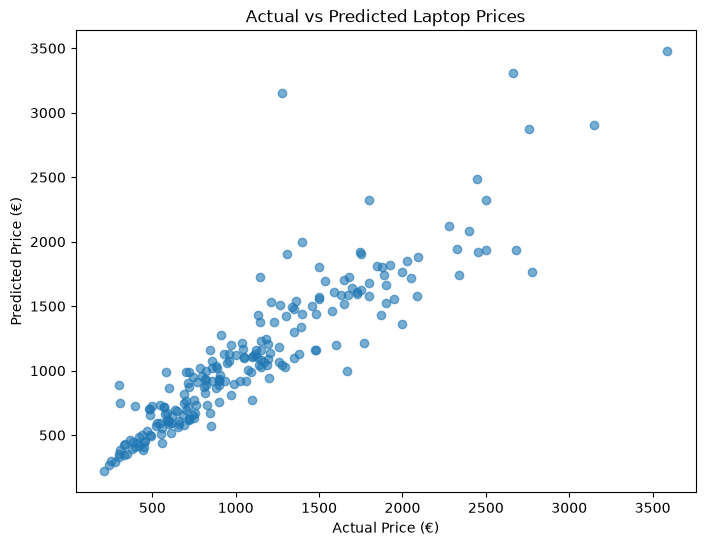

In [67]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.6)

plt.xlabel("Actual Price (€)")
plt.ylabel("Predicted Price (€)")
plt.title("Actual vs Predicted Laptop Prices")

plt.show()

In [68]:

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": rf_pred
})

comparison["Difference"] = (
    comparison["Actual Price"] -
    comparison["Predicted Price"]
)

print(comparison.head(10))

   Actual Price  Predicted Price  Difference
0        613.00       595.438862   17.561138
1       1064.00       917.252433  146.747567
2       1950.00      1552.116761  397.883239
3        689.00       576.641191  112.358809
4        638.00       692.433680  -54.433680
5        559.00       437.774594  121.225406
6        819.00       928.027785 -109.027785
7       1199.00       943.045245  255.954755
8        899.00       917.317389  -18.317389
9        818.35       829.640935  -11.290935


In [69]:
def predict_laptop_price(
    company,
    typename,
    inches,
    cpu_brand,
    gpu_brand,
    opsys,
    ram,
    ssd,
    hdd,
    total_storage,
    resolution_width,
    resolution_height,
    pixels,
    weight
):
    
    new_laptop = pd.DataFrame([{
        "Company": company,
        "TypeName": typename,
        "Inches": inches,
        "CPU_Brand": cpu_brand,
        "GPU_Brand": gpu_brand,
        "OpSys": opsys,
        "Ram (GB)": ram,
        "SSD_GB": ssd,
        "HDD_GB": hdd,
        "Total_Storage_GB": total_storage,
        "Resolution_Width": resolution_width,
        "Resolution_Height": resolution_height,
        "Pixels": pixels,
        "Weight (Kg)": weight
    }])

    new_laptop_encoded = preprocessor.transform(new_laptop)

    prediction = rf_model.predict(new_laptop_encoded)

    return prediction[0]

In [70]:

price = predict_laptop_price(
    company="Lenovo",
    typename="Notebook",
    inches=15.6,
    cpu_brand="Intel",
    gpu_brand="Intel",
    opsys="Windows 10",
    ram=8,
    ssd=256,
    hdd=0,
    total_storage=256,
    resolution_width=1920,
    resolution_height=1080,
    pixels=1920*1080,
    weight=1.8
)

print("Predicted Laptop Price: €", round(price, 2))

Predicted Laptop Price: € 1253.0


In [72]:
price = predict_laptop_price(
    company="Dell",
    typename="Gaming",
    inches=15.6,
    cpu_brand="Intel",
    gpu_brand="Nvidia",
    opsys="Windows 10",
    ram=16,
    ssd=512,
    hdd=0,
    total_storage=512,
    resolution_width=1920,
    resolution_height=1080,
    pixels=1920*1080,
    weight=2.5
)

print("Predicted Laptop Price: €", round(price, 2))

Predicted Laptop Price: € 1341.82


In [73]:
from sklearn.model_selection import cross_val_score
import numpy as np

rf_cv_scores = cross_val_score(
    rf_model,
    X_train_encoded,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation R² Scores:")
print(rf_cv_scores)

print("\nAverage R² Score:", round(rf_cv_scores.mean(), 4))
print("Standard Deviation:", round(rf_cv_scores.std(), 4))

Cross Validation R² Scores:
[0.77601502 0.73976576 0.81559636 0.82289792 0.80840554]

Average R² Score: 0.7925
Standard Deviation: 0.0309


In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after encoding
feature_names = preprocessor.get_feature_names_out()

# Get feature importance from Random Forest
importance = rf_model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15
print(feature_importance.head(15))

                      Feature  Importance
31              num__Ram (GB)    0.614546
38           num__Weight (Kg)    0.132193
32                num__SSD_GB    0.031656
12         cat__Company_Razer    0.027483
22  cat__TypeName_Workstation    0.024849
34      num__Total_Storage_GB    0.022458
20     cat__TypeName_Notebook    0.018226
30                num__Inches    0.016877
37                num__Pixels    0.015652
35      num__Resolution_Width    0.014543
36     num__Resolution_Height    0.011183
1           cat__Company_Asus    0.009097
8         cat__Company_Lenovo    0.008602
3           cat__Company_Dell    0.007809
5             cat__Company_HP    0.005921


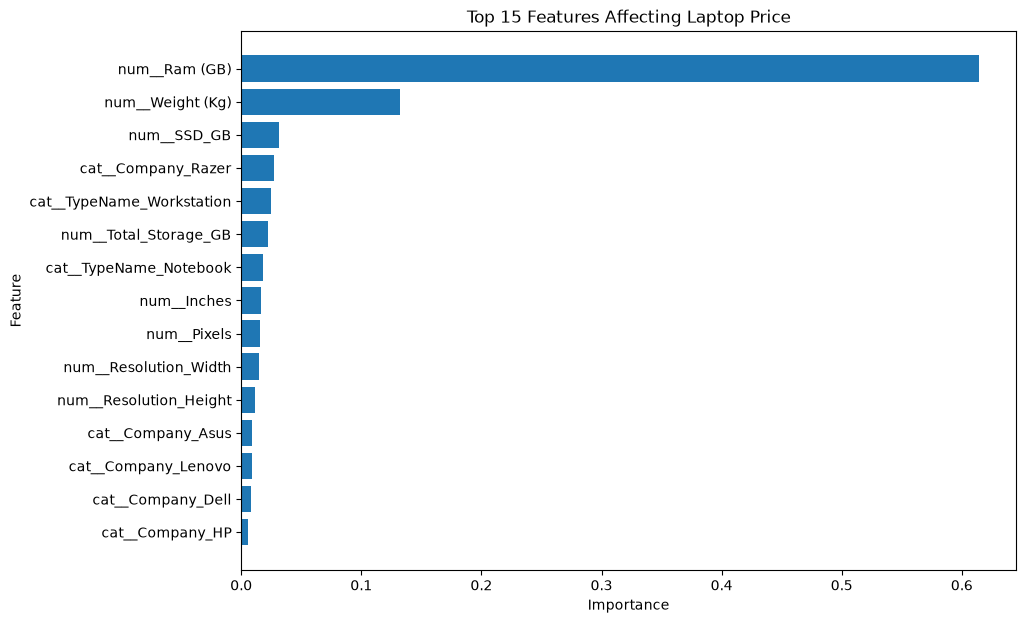

In [75]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Affecting Laptop Price")

plt.show()

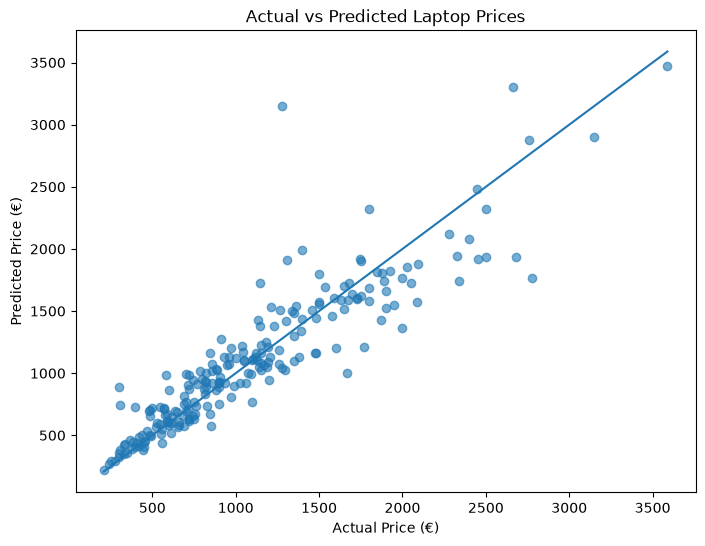

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.6
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price (€)")
plt.ylabel("Predicted Price (€)")
plt.title("Actual vs Predicted Laptop Prices")

plt.show()

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate prediction errors
errors = y_test - rf_pred

print("Mean Error:", round(errors.mean(), 2))
print("Mean Absolute Error:", round(np.abs(errors).mean(), 2))
print("Maximum Error:", round(np.abs(errors).max(), 2))

Mean Error: -3.15
Mean Absolute Error: 166.43
Maximum Error: 1871.17


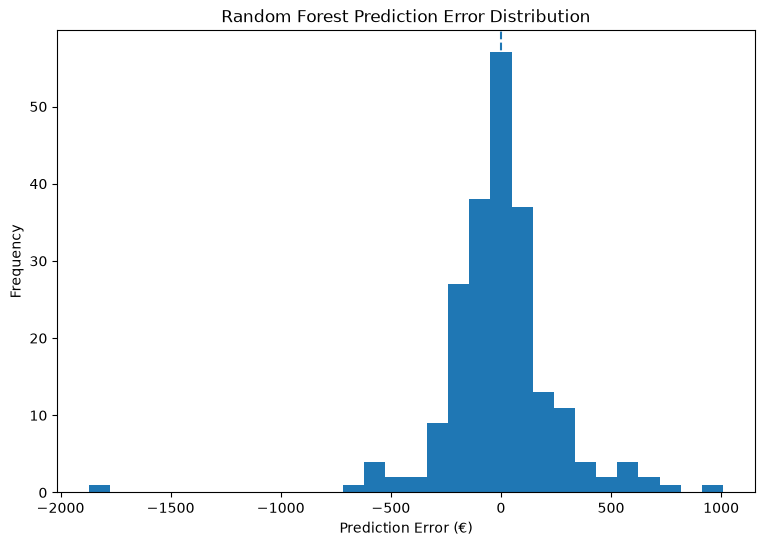

In [78]:
plt.figure(figsize=(9, 6))

plt.hist(errors, bins=30)

plt.xlabel("Prediction Error (€)")
plt.ylabel("Frequency")
plt.title("Random Forest Prediction Error Distribution")

plt.axvline(0, linestyle="--")

plt.show()

In [79]:
def evaluate_laptop_deal(actual_price, predicted_price):

    difference = actual_price - predicted_price

    if difference <= -100:
        status = "🔥 Great Deal"
        
    elif difference <= 100:
        status = "✅ Fair Price"
        
    elif difference <= 300:
        status = "⚠️ Slightly Expensive"
        
    else:
        status = "❌ Expensive"

    return status, difference

In [80]:
actual_price = 700

predicted_price = price

status, difference = evaluate_laptop_deal(
    actual_price,
    predicted_price
)

print("Predicted Price: €", round(predicted_price, 2))
print("Actual Price: €", actual_price)
print("Difference: €", round(difference, 2))
print("Verdict:", status)

Predicted Price: € 1341.82
Actual Price: € 700
Difference: € -641.82
Verdict: 🔥 Great Deal


In [81]:
import joblib

joblib.dump(rf_model, "techprice_rf_model.pkl")
joblib.dump(preprocessor, "techprice_preprocessor.pkl")

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [82]:
import os

print(os.path.exists("techprice_rf_model.pkl"))
print(os.path.exists("techprice_preprocessor.pkl"))

True
True
